In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
# add Code folder
import sys
sys.path.append('../qdarts')

# import main class and plotting function
from experiment import Experiment
from plotting import plot_polytopes

# import standard libraries
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec



## Device definition

In [3]:
# Define the system

#All capacitances are given in aF
N = 3 #number of dots   
C_DD=20* np.eye((N))/2 #The self-capacitance of each dot, NOTE: factor of 2 due to symmetrization
C_DD[0,1] = 10 #capacitance between dot 0 and dot 1 (Left double dot) 
C_DD[1,2] = 5 #capacitance between dot 1 and dot 2 (Right double dot)
C_DD[0,2] = 1 #capacitance between dot 0 and dot 2

C_DD = C_DD + C_DD.T

C_DG=11*np.eye(N) #dot-to-gate capacitances 
#cross-capacitances
C_DG[0,1] = 1.5 #dot 0 from dot 1
C_DG[1,0] = 1.2 #dot 1 from dot 0

# Definition of the tunnel couplings in eV 
# NOTE: we use the convention that tc is the energy gap at avoided crossing H = tc/2 sx
tunnel_couplings = np.zeros((N,N))
tunnel_couplings[0,1] = 100*1e-6


In [4]:
capacitance_config = {
        "C_DD" : C_DD,  #dot-dot capacitance matrix
        "C_Dg" : C_DG,  #dot-gate capacitance matrix
        "ks" : 4,       #distortion of Coulomb peaks. NOTE: If None -> constant size of Coublomb peak 
}

tunneling_config = {
        "tunnel_couplings": tunnel_couplings, #tunnel coupling matrix
        "temperature": 0.1,                   #temperature in Kelvin
        "energy_range_factor": 2,  #energy scale for the Hamiltonian generation. NOTE: Smaller -> faster but less accurate computation 
}
sensor_config = {
        "sensor_dot_indices": [2],  #Indices of the sensor dots
        "sensor_detunings": [-0.0005],  #Detuning of the sensor dots
        "noise_amplitude": {"fast_noise": 0.8*1e-4, "slow_noise": 1e-6}, #Noise amplitude for the sensor dots in eV
        "peak_width_multiplier": 15,  #Width of the sensor peaks in the units of thermal broadening m *kB*T/0.61.
}


In [5]:
# Create the experiment object from the configuration files
experiment = Experiment(capacitance_config, tunneling_config, sensor_config)

EXPERIMENT INITIALIZED
-----------------------

                Capacitance model deployed with the following parameters:
                Dot-dot capacitances: 
                [[20. 10.  1.]
 [10. 20.  5.]
 [ 1.  5. 20.]]
                Dot-gate capacitances: 
                [[11.   1.5  0. ]
 [ 1.2 11.   0. ]
 [ 0.   0.  11. ]]
                Size of Coulomb peaks V[n] is constant
                

            Sensor model deployed with the following parameters:   
            Sensor dot indices: [2]
            Sensor detunings: [-0.5] meV
            Coulomb peak width: 0.41 meV
            Slow noise amplitude: 1.0 ueV
            Fast noise amplitude: 80.0 ueV
            

            Tunneling model deployed with the following parameters:
            Tunneling matrix:
            [[0.e+00 1.e-04 0.e+00]
 [0.e+00 0.e+00 0.e+00]
 [0.e+00 0.e+00 0.e+00]]
            Temperature: 0.1 K
            Energy range factor: 2
            


In [6]:
xexp, yexp, _, polytopesexp, sensor_signalexp, _ = experiment.generate_CSD(
                                    plane_axes = np.array([[1,0,0],[0,1,0]]), # vectors spanning the cut in voltage space
                                    target_state = [1,0,10],  # target state for transition
                                    target_transition = [-1,1,0], #target transition from target state, here transition to [2,3,2,3,5,5]
                                    x_voltages=np.linspace(-0.005, 0.012, 100), #voltage range for x-axis
                                    y_voltages=np.linspace(-0.005, 0.005, 100), #voltage range for y-axis
                                    compute_polytopes = True, #compute the corners of constant occupation
                                    compensate_sensors=True, #compensate the sensor signals
                                    use_virtual_gates=True, #use the virtual gates
                                    use_sensor_signal=True) #use the sensor signals

v_offset found: [0.00646556 0.00695216]


In [7]:
# Control plot

def plot_CSD(xexp, yexp, sensor_signalexp, polytopesexp, x0,x1):
    fig, ax = plt.subplots(1,1)
    plt.subplots_adjust(wspace=0.5, hspace=0.5)
    #Conductance of the dot 4 (Left sensor dot)
    #ax.set_title("Sensor 4", fontsize=14)
    ax.pcolormesh(1e3*xexp,1e3*yexp,sensor_signalexp[:,:,0])
    plot_polytopes(ax,polytopesexp, axes_rescale=1e3)  # plot the polytopes to see the constant occupation regions
    print(xexp[0],yexp[0])
    ax.set_xlim(xexp[0]*1e3,xexp[-1]*1e3)
    ax.set_ylim(yexp[0]*1e3,yexp[-1]*1e3) 
    plt.plot([x0[0],x1[0]],[x0[1],x1[1]], 'k-', linewidth=2, zorder=5)
    #plt.quiver((x0[0]+x1[0])/2*1e3,(x0[1]+x1[1])/2*1e3, np.diff(x0), np.diff(x1), angles='xy', scale_units='xy', scale=1, color='black')

-0.005 -0.005


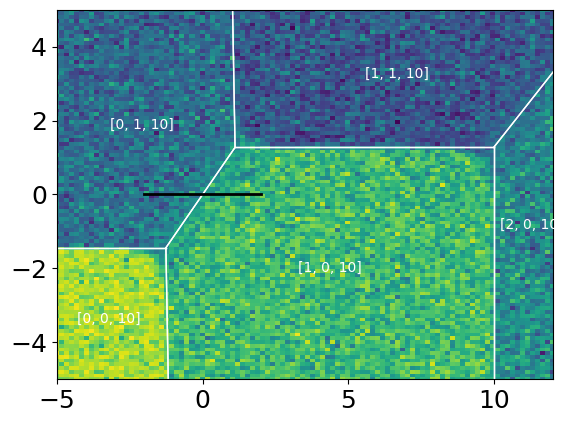

In [9]:
## Let's do latching
Initial_position = np.array([-2*1e-3,0,0])
Final_position = np.array([2*1e-3,0,0])
plot_CSD(xexp, yexp, sensor_signalexp, polytopesexp, np.array(Initial_position)*1e3, np.array(Final_position)*1e3)


[-0.002  0.     0.   ]
[[-0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00]
 [ 0.00000000e+00  2.24028482e-03  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00  7.70571934e-03  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  1.51679443e-02
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   1.98428704e-03  0.00000000e+00  0.00000000e+00 -1.00000000e-04
   0.00000000e+00  0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  4.73764523e-03  0.00000000e+00  0.00000000e+00
  -1.00000

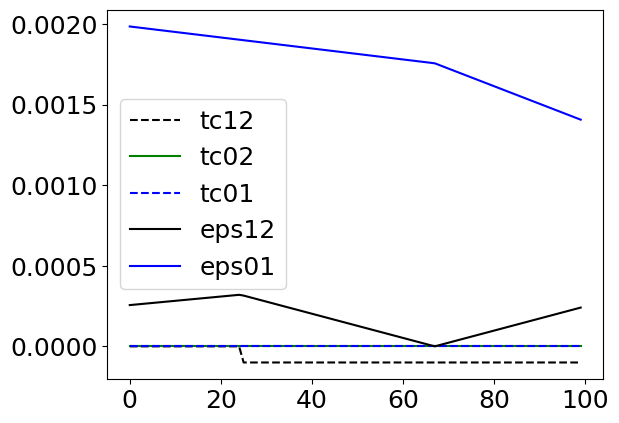

In [10]:
steps = 100
depses = (Final_position - Initial_position)/steps
eps01 = []
eps12 = []
tcs01 = []
tcs02 = []
tcs12 = []
for k in range(steps):
    H = experiment.tunneling_sim.get_Hamiltonian(Initial_position+k*depses, [0,1,5])
    print(Initial_position+k*depses)
    print(H)
    inds = np.argsort(np.diag(H))[:3]
    Heff = np.zeros((3,3))
    for n,ind in enumerate(inds):
        for m, ind2 in enumerate(inds):
            Heff[n,m] = H[ind,ind2]

    tcs12.append(Heff[1,2])
    tcs02.append(Heff[0,2])
    tcs01.append(Heff[0,1])
    eps12.append(Heff[2,2]-Heff[1,1])
    eps01.append(Heff[1,1]-Heff[0,0])
    #plt.figure()
    #plt.imshow(Heff)

    # 
plt.plot(tcs12, "--k", label='tc12')
plt.plot(tcs02, "g",label='tc02')
plt.plot(tcs01, "--b", label = 'tc01')   
plt.plot(eps12, '-k', label='eps12')
plt.plot(eps01, "-b",label='eps01')  

plt.legend()
   
    


In [58]:
tcs

[0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0]

[[7.07106781e-01]
 [1.56526742e+05]]
[[1.19486185e+00]
 [1.07969848e+05]]
[[1.51197988e+00]
 [7.27290619e+04]]
[[1.7090337e+00]
 [4.8193853e+04]]
[[1.82702464e+00]
 [3.15803883e+04]]
[[1.89515567e+00]
 [2.05348919e+04]]
[[1.93269875e+00]
 [1.32791511e+04]]
[[1.95178035e+00]
 [8.55117321e+03]]
[[1.95979460e+00]
 [5.48759005e+03]]
[[1.96114990e+00]
 [3.51071932e+03]]
[[1.95842825e+00]
 [2.23932486e+03]]
[[   1.95311963]
 [1424.02087739]]
[[  1.9460766]
 [902.6266507]]
[[  1.93779597]
 [570.10950799]]
[[  1.92860081]
 [358.66269903]]
[[  1.91877493]
 [224.62732599]]
[[  1.90869206]
 [139.96019235]]
[[ 1.89898741]
 [86.69087966]]
[[ 1.89084793]
 [53.33198819]]
[[ 1.88657849]
 [32.56028115]]
[[ 1.89082522]
 [19.72257872]]
[[ 1.91349664]
 [11.87635078]]
[[1.9775666 ]
 [7.17815736]]
[[2.14225727]
 [4.5021924 ]]
[[2.57028247]
 [3.20856457]]
[[3.55453767]
 [2.84743089]]
[[0.93767195]
 [2.02468848]]
[[29.7038693]
 [66.3726657]]
[[2.67080421]
 [8.25497721]]
[[ 2.84145312]
 [11.67506955]]
[[ 2.854

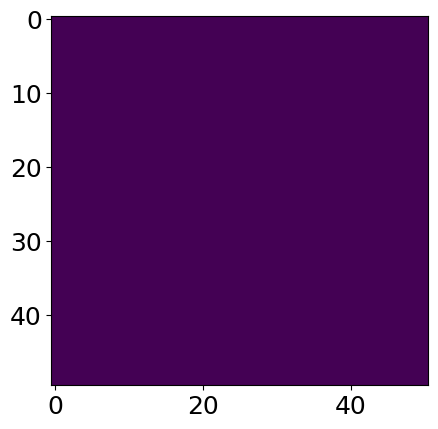

In [104]:
### Model case
V = np.linspace(-5,5,51)
E1 = lambda v: v
E2 = lambda v: -v

K = 50

CSD = np.zeros([K,len(V)])

gamma = lambda v: 1/np.sqrt(v**2+1**2)

N = 2
for k in range(K):
    state = np.zeros((N,1))
    state[-1] = 1
    for vn,v in enumerate(V):
        dE = E1(v) - E2(v)
        gp = gamma(dE)*np.exp(-np.abs(dE))
        gm = gamma(dE)
        M = np.array([[-gm, gp],[gm,-gp]])

plt.imshow(CSD)
